# Second Notebook: Quantitative Analysis of a High-Redshift Quasar Candidate

This notebook represents the second stage of the analysis and focuses on quantitative model comparison and best-fit selection.

In the first notebook, the observational data were normalized, rescaled to photometric reference points, resampled into uniform wavelength bins, and compared with preliminary brown dwarf (M, L, and T) and quasar templates (median, high, and low Lyα emission). Based on these initial tests, the M-dwarf and median Lyα quasar templates were selected for further analysis.

This notebook:

* Incorporates additional LBT spectroscopic data.
* Resamples the finalized dataset and selected templates under consistent binning.
* Performs automated template fitting through an iterative scaling loop.
* Includes the best-fit contribution of M-dwarf and median Lyα quasar templates.
* Evaluates model performance using reduced χ².
* Identifies the most plausible physical scenario.

The objective is to perform a quantitative comparison between competing hypotheses through template-based fitting and reduced χ² analysis.

In [2]:
#Import libraries
import numpy as np
import matplotlib.pyplot  as plt
import astropy
from astropy.io import fits
from photutils.aperture import aperture_photometry
#not. sure about these two
from photutils.aperture import CircularAnnulus, CircularAperture, SkyCircularAperture, SkyCircularAnnulus 
from photutils.aperture import ApertureStats
from astropy.visualization import simple_norm
from astropy.wcs import WCS
import os
from astropy.coordinates import SkyCoord
from astropy import units as u
#from sculptor import speconed as sod
#import pkg_resources
from astropy import units as u
#from sculptor import speconed as sod
from astropy import units as u
from astropy.table import Table
from scipy.optimize import curve_fit
import pkg_resources

## Import data

### Templates

In [5]:
#Redshift to test 
z=6.38

<Table length=960>
    name     dtype   unit                 description                
----------- ------- ------ ------------------------------------------
       Wave float64 0.1 nm                    Wavelength in Angstroms
      FluxD float64     --        Flux density PS1 composite spectrum
          N   int32     --       Number of quasars per wavelength bin
FluxD(hlya) float64     -- Flux density strong lya composite spectrum
FluxD(llya) float64     --   Flux density weak lya composite spectrum


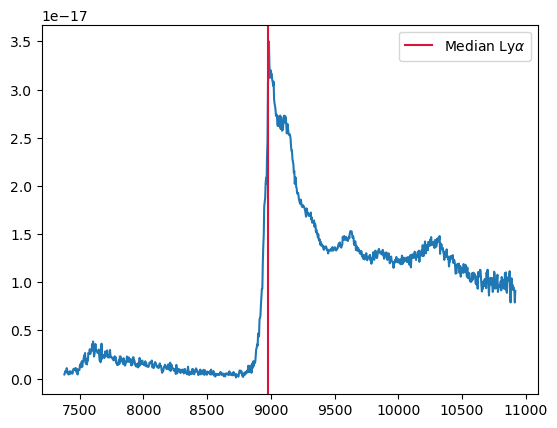

In [6]:
#Import data from Banados 2016 template / scale to flux units
compositehrspectra=Table.read('compositespectra.txt',format='ascii')
compositehrspectra.info()
composite_flux=compositehrspectra['FluxD']*1e-16/(z+1)
composite_wave=compositehrspectra['Wave']*(z+1)
plt.plot(composite_wave,composite_flux)
plt.axvline(1216*(z+1),color='crimson', label=r'Median Ly$\alpha$')
plt.legend()

(7380.738, 83760.78600000001)

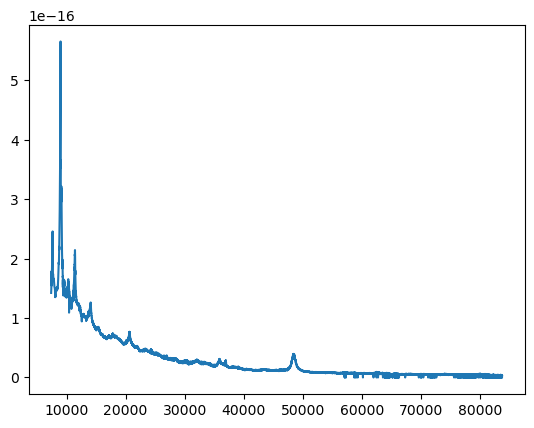

In [7]:
#Import data from Selsing template / scale to flux units and redshift
data = np.loadtxt('Selsing2015.dat', delimiter=' ')
wl=data[:,0]*(z+1)
weighted_mean=data[:,1]*1e-17
error_of_weighted_mean=data[:,2]*1e-17/(z+1)
#Plot to see Selsing data
plt.plot(wl,weighted_mean)
#Print first and last wavelength
wl[0],wl[-1]

### Import real data 
Including GMOS+ F2 and the LBT data (this data was not in the other notebook since it was included after mansucript submission).

In [9]:
#Load original data from Gemini (GMOS and F2) Note: GMOS up to 9660, F2 starts 14250
originaldata=Table.read('spectra_gmos_fla_2_v2.txt', format='ascii')
#Check columns and dtype
originaldata.info

<Table length=4588>
   name     dtype 
---------- -------
WAVELENGTH float64
      FLUX float64
       ERR float64

In [10]:
originaldata['WAVELENGTH'][0],originaldata['WAVELENGTH'][-1]

(7144.467185079627, 24193.306652501036)

In [11]:
#Load LBT data (scaled to z-band PanSTARSS) / gap within original data
lbtdata=Table.read('P170+20_LUCI_coadd_zps_tellcorr.fits')
#Check columns
lbtdata.info

<Table length=2069>
     name      dtype 
------------- -------
         wave float64
wave_grid_mid float64
         flux float64
         ivar float64
        sigma float64
         mask   int64
     telluric float64
    obj_model float64

In [12]:
hdul=fits.open('P170+20_LUCI_coadd_zps_tellcorr.fits')
print(hdul[1].header)

XTENSION= 'BINTABLE'           / binary table extension                         BITPIX  =                    8 / array data type                                NAXIS   =                    2 / number of array dimensions                     NAXIS1  =                   64 / length of dimension 1                          NAXIS2  =                 2069 / length of dimension 2                          PCOUNT  =                    0 / number of group parameters                     GCOUNT  =                    1 / number of groups                               TFIELDS =                    8 / number of table fields                         VERSPYT = '3.12.4  '           / Python version                                 VERSNPY = '2.1.0   '           / Numpy version                                  VERSSCI = '1.14.1  '           / Scipy version                                  VERSAST = '6.1.2   '           / Astropy version                                VERSSKL = '1.5.1   '           / Scikit-

(9381.54210557767, 13808.157537769772)

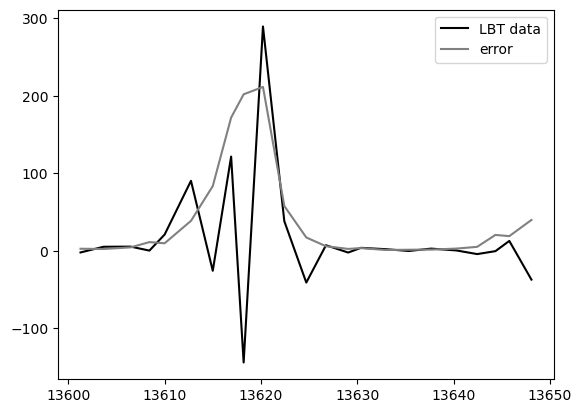

In [13]:
#Visualize data from LBT - There is a point that goes up to 300
filterlbt=(lbtdata['wave']>13600) &(lbtdata['wave']<13650)
plt.plot(lbtdata['wave'][filterlbt],lbtdata['flux'][filterlbt],color='black',label='LBT data')
plt.plot(lbtdata['wave'][filterlbt],(lbtdata['sigma'][filterlbt]),color='gray', label='error')
plt.legend()
lbtdata['wave'][0],lbtdata['wave'][-1]

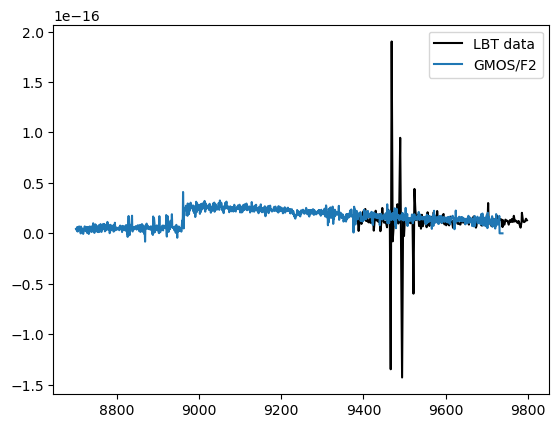

In [14]:
#GMOS and LBT overlap, GMOS is 9660 and lbt starts at 9381
filterlbt1=(lbtdata['wave']>8700) &(lbtdata['wave']<9800)
filtergmos=(originaldata['WAVELENGTH']>8700) &(originaldata['WAVELENGTH']<9800)
plt.plot(lbtdata['wave'][filterlbt1],lbtdata['flux'][filterlbt1]*1e-17,color='black',label='LBT data')
plt.plot(originaldata['WAVELENGTH'][filtergmos],originaldata['FLUX'][filtergmos],label='GMOS/F2')
plt.legend()

In [15]:
#Clean spikes of lbt
from astropy.stats import sigma_clip

clipped=sigma_clip(
lbtdata['flux'],
sigma=5,
maxiters=5
)

lbt_clean=lbtdata['flux'].copy()

bad=clipped.mask
good=~bad

lbt_clean[bad]=np.interp(
lbtdata['wave'][bad],
lbtdata['wave'][good],
lbt_clean[good]
)

## Resample data to GMOS pixel size 

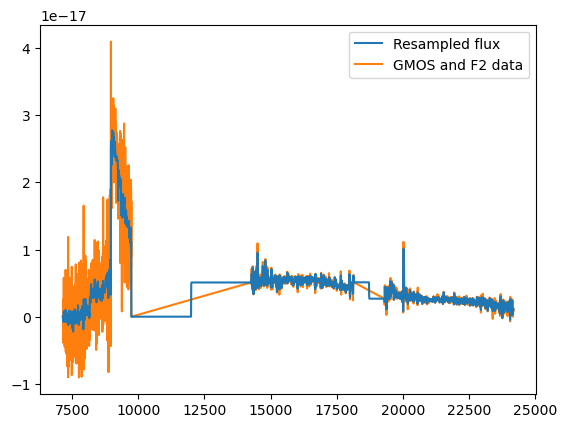

In [17]:
#Resample original data with FluxConservingResampler
#Include resample data/ pix_size=7.7 of GMOS data (lowest size)
import astropy.units as units
from specutils.manipulation import FluxConservingResampler
#First Give units to variables with filtered data
#First with original data
newflux=originaldata['FLUX']* units.erg/units.s/units.cm**2/units.AA
newwave=originaldata['WAVELENGTH']*1.*units.AA
newerr=originaldata['ERR'] * units.erg/units.s/units.cm**2/units.AA

#convert to SpectrumID object from specutils 
from specutils import Spectrum1D
input_spec=Spectrum1D(spectral_axis=newwave,flux=newflux) 
input_spec_err=Spectrum1D(spectral_axis=newwave,flux=newerr)

#Resample here
new_disp_grid = np.arange(5300, 24185.793, 7.7) * u.AA # inwave,finwave,pixsize (first and last wave from original data+GMOS pix size)
#Create object to resample
fluxcon = FluxConservingResampler()
#Resample flux data and error
new_spec_fluxcon = fluxcon(input_spec, new_disp_grid)
new_spec_fluxcon_err = fluxcon(input_spec_err, new_disp_grid)

#Plot original data and resampled original data
plt.plot(new_spec_fluxcon.spectral_axis,new_spec_fluxcon.flux, label='Resampled flux')
plt.plot(newwave,newflux,zorder=1, label='GMOS and F2 data')
plt.legend()

C:\Users\aurom\AppData\Local\Temp\ipykernel_55728\21498276.py:6: RuntimeWarning: divide by zero encountered in divide
  lbterr=(1/np.sqrt(lbtdata['ivar'])) *flux_unit


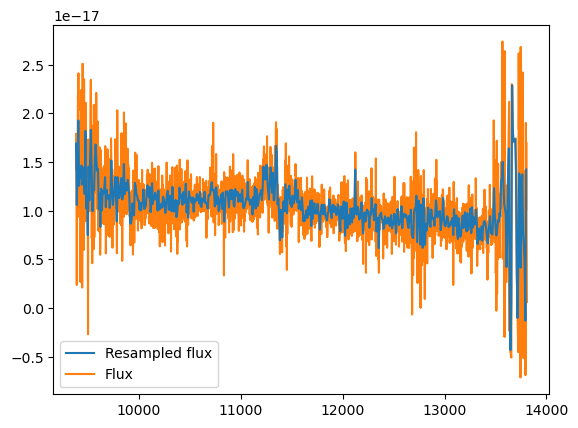

In [18]:
#Resample lbt data
#Lbt data give units and scale
flux_unit=1e-17*units.erg/units.s/units.cm**2/units.AA
lbtflux=lbt_clean*flux_unit
lbtwave=lbtdata['wave']*units.AA
lbterr=(1/np.sqrt(lbtdata['ivar'])) *flux_unit

#convert to Spectrum 
from specutils import Spectrum1D
input_spec=Spectrum1D(spectral_axis=lbtwave,flux=lbtflux) 
input_spec_err=Spectrum1D(spectral_axis=lbtwave,flux=lbterr)

#Resample here, use the same resample object and grid #(9381.54210557767, 13808.157537769772)
lbt_spec_fluxcon = fluxcon(input_spec, new_disp_grid)
lbt_spec_fluxcon_err = fluxcon(input_spec_err, new_disp_grid)

lbt_flux_values=lbt_spec_fluxcon.flux.to(flux_unit).value
lbt_err_values=lbt_spec_fluxcon_err.flux.to(flux_unit).value

#Plot to see the new data
plt.plot(lbt_spec_fluxcon.spectral_axis,lbt_spec_fluxcon.flux, label='Resampled flux')
plt.plot(lbtwave,lbtflux,zorder=1,label='Flux')
plt.legend()

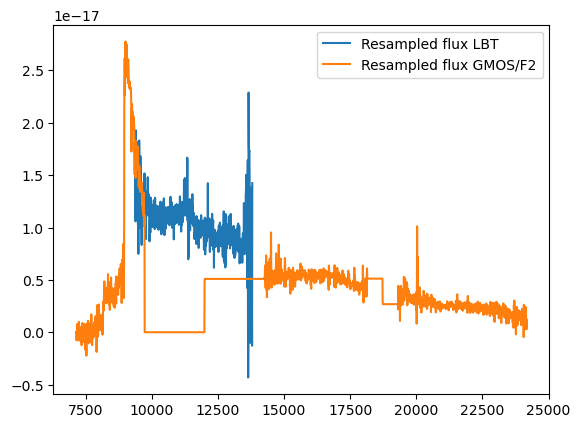

In [19]:
#Plot all resampled data GMOC,LBT,F2
plt.plot(lbt_spec_fluxcon.spectral_axis,lbt_spec_fluxcon.flux, label='Resampled flux LBT')
plt.plot(new_spec_fluxcon.spectral_axis,new_spec_fluxcon.flux, label='Resampled flux GMOS/F2')
plt.legend()

### Resample templates

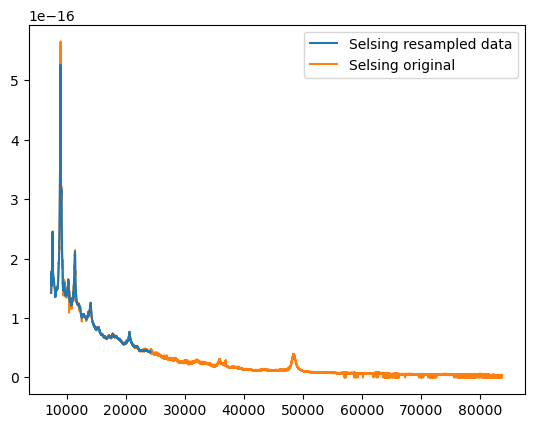

In [21]:
#Resample templates ----> Selsing
#Include resample data/ pix_size=7.7
#Selsing data
newfluxs=weighted_mean* units.erg/units.s/units.cm**2/units.AA
newwaves=wl*units.AA
newerrs=error_of_weighted_mean* units.erg/units.s/units.cm**2/units.AA

#Convert to Spectrum1D
input_specs=Spectrum1D(spectral_axis=newwaves,flux=newfluxs) 
input_spec_errs=Spectrum1D(spectral_axis=newwaves,flux=newerrs)

#Resample here using same object fluxcons and grid
new_spec_fluxcons = fluxcon(input_specs, new_disp_grid)
new_spec_fluxcon_errs = fluxcon(input_spec_errs, new_disp_grid)

#Plot Selsing data before and after
plt.plot(new_spec_fluxcons.spectral_axis,new_spec_fluxcons.flux, label='Selsing resampled data')
plt.plot(newwaves,newfluxs,zorder=1, label='Selsing original')
plt.legend()

### Note: Selsing data was shortened because of the resample to match all the rest of the available data

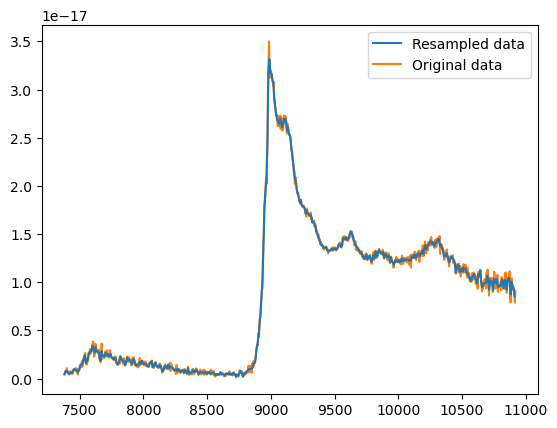

In [23]:
#Resample templates ----> Banados Intermediate (The chosen template to fit-Lyman alpha intermediate)
#Banados intermediate data
newfluxc=composite_flux.value*units.erg/units.s/units.cm**2/units.AA 
newwavec=composite_wave.value*1.*units.AA

#convert to Spectrum 
input_specc=Spectrum1D(spectral_axis=newwavec,flux=newfluxc) 

#Resample same grid same object
new_spec_fluxconc = fluxcon(input_specc, new_disp_grid)

#Plot Banados data before and after resample
plt.plot(new_spec_fluxconc.spectral_axis,new_spec_fluxconc.flux,label='Resampled data')
plt.plot(newwavec,newfluxc,zorder=1,label='Original data')
plt.legend()

## Here all the resampled data -> Join templates: Intermediate Comp Spectra with Selsing

In [25]:
#Rename data and joined LBT with original data
originaldata_wave=new_spec_fluxcon.spectral_axis.value.copy()
originaldata_flux=new_spec_fluxcon.flux.value.copy()
originaldata_err=new_spec_fluxcon_err.flux.value.copy()

mask_replace=(originaldata_wave>=9660)&(originaldata_wave<=13500) #Last wave in GMOS data and last LBT wave 13808.157537769772

originaldata_flux[mask_replace]=lbt_spec_fluxcon.flux.value[mask_replace]
originaldata_err[mask_replace]=lbt_spec_fluxcon_err.flux.value[mask_replace]


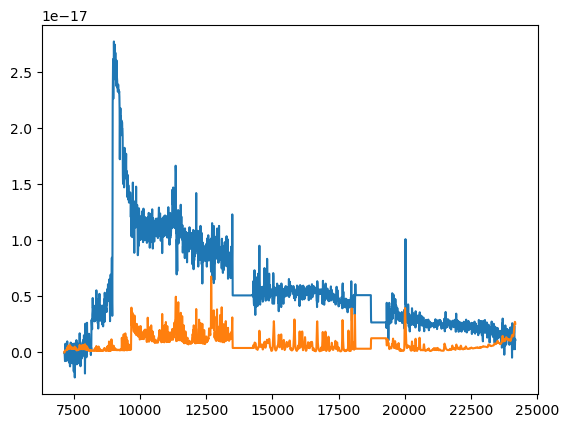

In [26]:
#Plot all joined data
plt.plot(originaldata_wave,originaldata_flux,label='Final data: GMOS/LBT/F2')
plt.plot(originaldata_wave,originaldata_err)

In [27]:
#Rename resampled data again
#Selsing data
wl=new_spec_fluxcons.spectral_axis.value 
weighted_mean=new_spec_fluxcons.flux.value 
#Banados data composite/intermediate
composite_wave=new_spec_fluxconc.spectral_axis.value
composite_flux=new_spec_fluxconc.flux.value

In [28]:
#Check wavelegth range of data
originaldata_wave[0],originaldata_wave[-1]

(5300.0, 24180.399999999554)

### Scientific step
We set the template to zero before zero. We do this to test the lensing hypothesis, where emission below Ly$\alpha$ is not expected at that redshift because of the interstellar medium absorption.

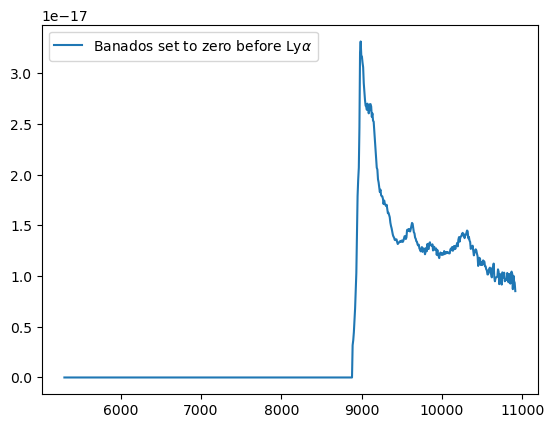

In [30]:
#Set banados template to zero before the break (we do not want any contribution of the template before Lyalpha)
maskzero=composite_wave < 1216*(1+z)-90 # allowing a small buffer to avoid cutting the Lyα emission profile too sharply.
composite_flux= np.where(maskzero, 0, composite_flux)
#Plot to see template set to zero
plt.plot(composite_wave,composite_flux, label=r'Banados set to zero before Ly$\alpha$')
plt.legend()

## Here are the joined templates
Templates are joined to the last wavelength of the Banados template 1479.5
Practice note: To match W1 photometric point 3.6 needs to be multiplied, to match the J band 1.8. At the end we use the average in a certain region between templates instead of matching the photometric detected points.

In [32]:
#Banados template last wavelength
composite_wave[-1]/(z+1)

3276.476964769587

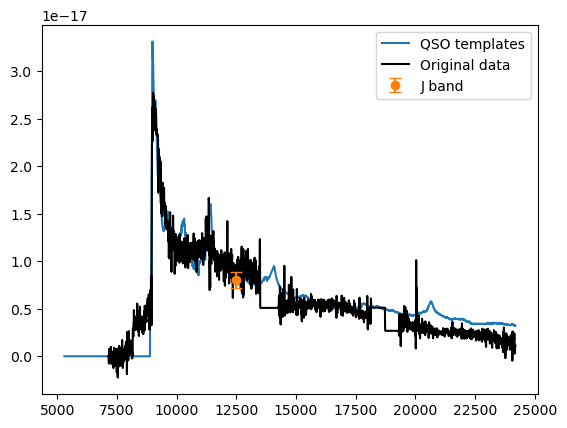

In [33]:
#Scale Selsing with comp/intermediate lyman alpha 
#Mask for the selsing template
maskcs2=wl>1479.5*(z+1)
#Mask for the banados template (in theory wave must be the same for resample)
maskpr=composite_wave<1479.5*(z+1)

#Create masks to calculate an average in a certain region to find the correct number to re scale the data / we do not use J1 or W1
selsingjoin=(wl>10850)&(wl<10900)
masksjoin=(composite_wave>10850)&(composite_flux<10900)
avgbanadosjoin=np.median(composite_flux[masksjoin])
averageselsingjoin=np.median(weighted_mean[selsingjoin])
averagejoin=avgbanadosjoin/averageselsingjoin

#Factor to test the data
factorj=4.2
#Factor to actually re scale the data
factorq=averagejoin

#Create new template for quasar contribution (Banados + Selsing) and save it in a table
tabc = astropy.table.Table()
tabc['WAVE']= np.append(composite_wave[maskpr],wl[maskcs2])
tabc['FLUX']= np.append(composite_flux[maskpr],weighted_mean[maskcs2]*factorq) #Note: this is multiplied by the factor to match data

#Plot templates, data and photometric points
#plt.plot(wl[selsingjoin], weighted_mean[selsingjoin],label='zone',color='magenta')
plt.plot(tabc['WAVE'],tabc['FLUX'],label='QSO templates')
plt.plot(originaldata_wave,originaldata_flux,label='Original data',color='black')
plt.plot()
#plt.errorbar(x=34000, y=7.19e-19, yerr=0.85e-18, fmt='o', capsize=4,label='W1 band')
#plt.errorbar(x=46000, y=2.28e-19, yerr=0.8e-18, fmt='o', capsize=4,label='W2 band')
#plt.plot(data[:,0]*(z+1),(data[:,1]*1e-17/(z+1))/factorj,label='selsing template') #to match with j band
plt.errorbar(x=12500, y=8.014e-18, yerr=0.85e-18, fmt='o', capsize=4,label='J band')
#plt.xlim(10000,12000)# to check break
#plt.xlim(30000,40000) #to check WI factors3=3.6
#plt.xlim(10000,13000) #to check the j band
#hERE TO CHeCK W1
#plt.plot(newwaves,newfluxs/2.1,zorder=1)
#plt.plot(composite_wave,composite_flux,label='banados template',linestyle='dotted')
#plt.plot(wl,weighted_mean,label='selsing template')
#tabc['FLUX'][27]

#plt.axvline(8980,color='red',label)

len(tabc['FLUX']),len(originaldata_flux),averagejoin,10850/(z+1),10900/(z+1)
plt.legend()

# Build model

### Step 1. Substraction of quasar contribution to our data

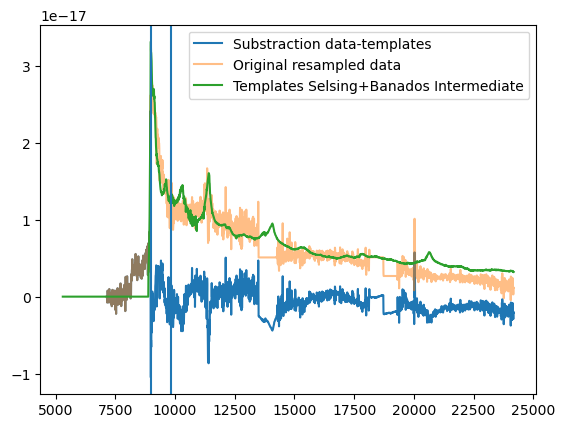

In [36]:
#Substraction data-model CLyman/Selsing
maskl=originaldata_wave>1216*(1+z) #mask to rest from Lyman alpha
maskl2=originaldata_wave<1216*(1+z)
a=originaldata_flux
d=tabc['FLUX']

#Do the substraction and save it in a new variable
result3 = a-d 
residual3=np.append(originaldata_flux[maskl2],result3[maskl]) #resta de data -templates sin contar zona mas alla de lyman

#Plot the substracted data
plt.plot(originaldata_wave,  residual3,label='Substraction data-templates' )
plt.plot(originaldata_wave,originaldata_flux,alpha=0.5,label='Original resampled data')
plt.plot(tabc['WAVE'],tabc['FLUX'],zorder=2,label='Templates Selsing+Banados Intermediate')
#plt.xlim(7700,10000)
plt.axvline(9000)
plt.axvline(1330*(z+1))
plt.legend()

## Following steps
The following steps are included in the function Mdwarf_function. 
### Step 2. Fit Mdwarf templates (157, available in Burgasser & Eldwain 2005) to the blue part of the Ly$\alpha$ region.
The fit was made with curve_fit.
M-dwarf models were resampled in the same grid as all data in the loop.
### Step 3. Residual data is fit with quasar templates
Several mask are implemented to fit residual data to quasar template (Median Ly$\alpha$+Selsing).
### Step 4. Evaluate the model using reduced $\chi^2$
The final model was selected and included in the currently submitted paper Mata-Sanchez et al, 2026.

Note: GMOS starts 7144.467185079627 at and ends at 9660,LBT ends 13808.157537769772, F2 starts 14250 and ends at 24193.306652501036. 

In [39]:
#This help us to build the masks
print(7144.467185079627/(z+1) ,9660/(z+1),14250/(z+1), 13808.157537769772/(z+1),  14250/(z+1) , 24193.306652501036/(z+1))

968.0849844281337 1308.9430894308944 1930.8943089430895 1871.0240566083703 1930.8943089430895 3278.225833672227


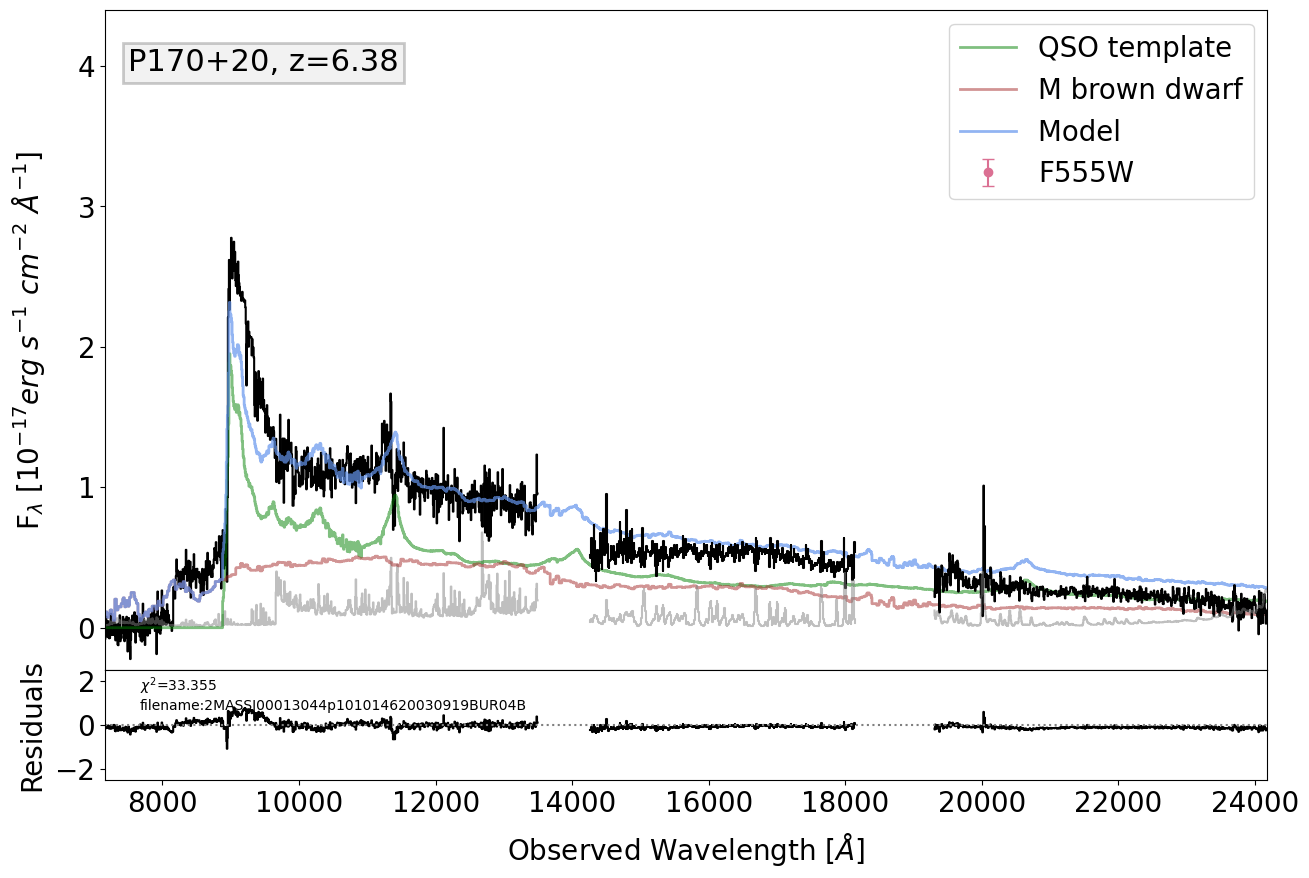

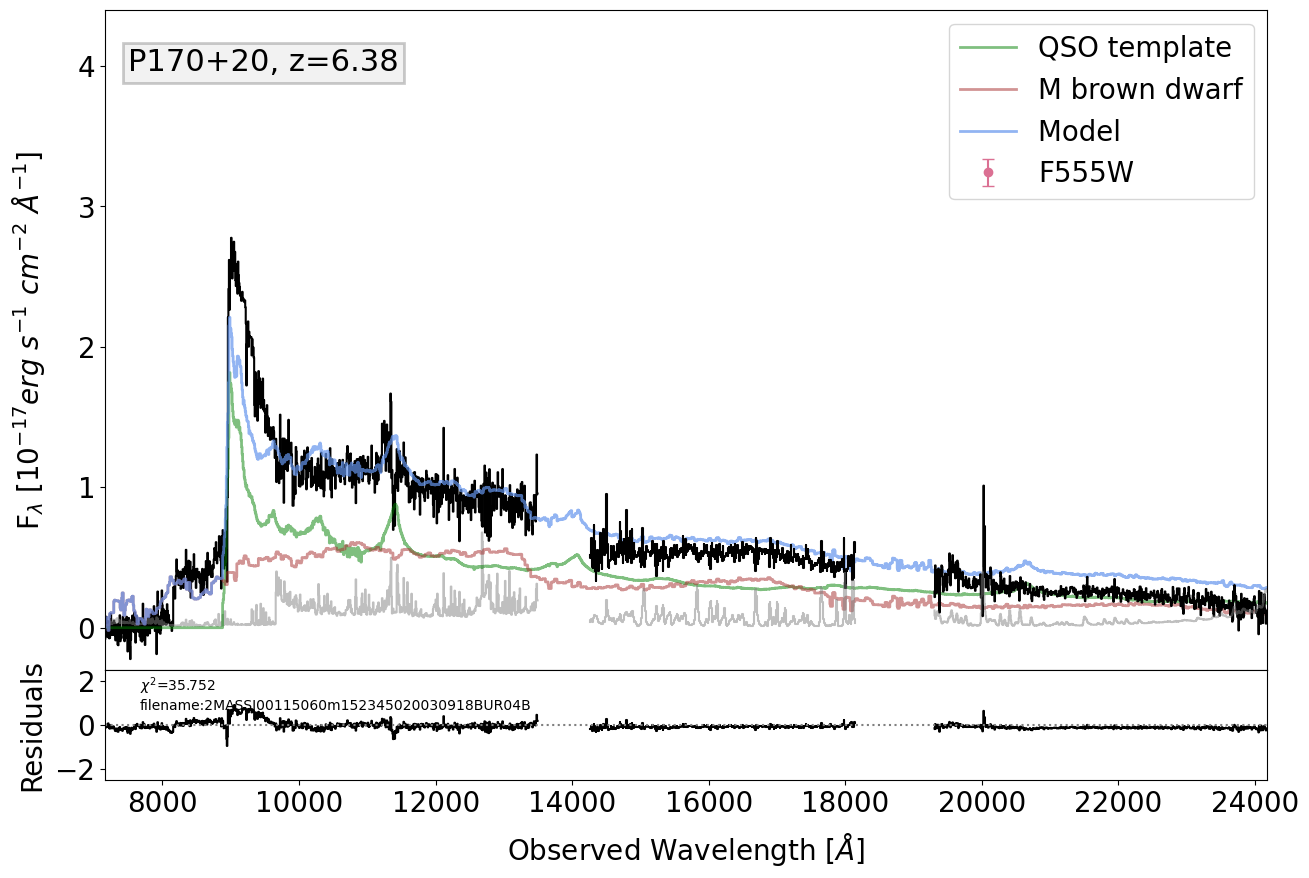

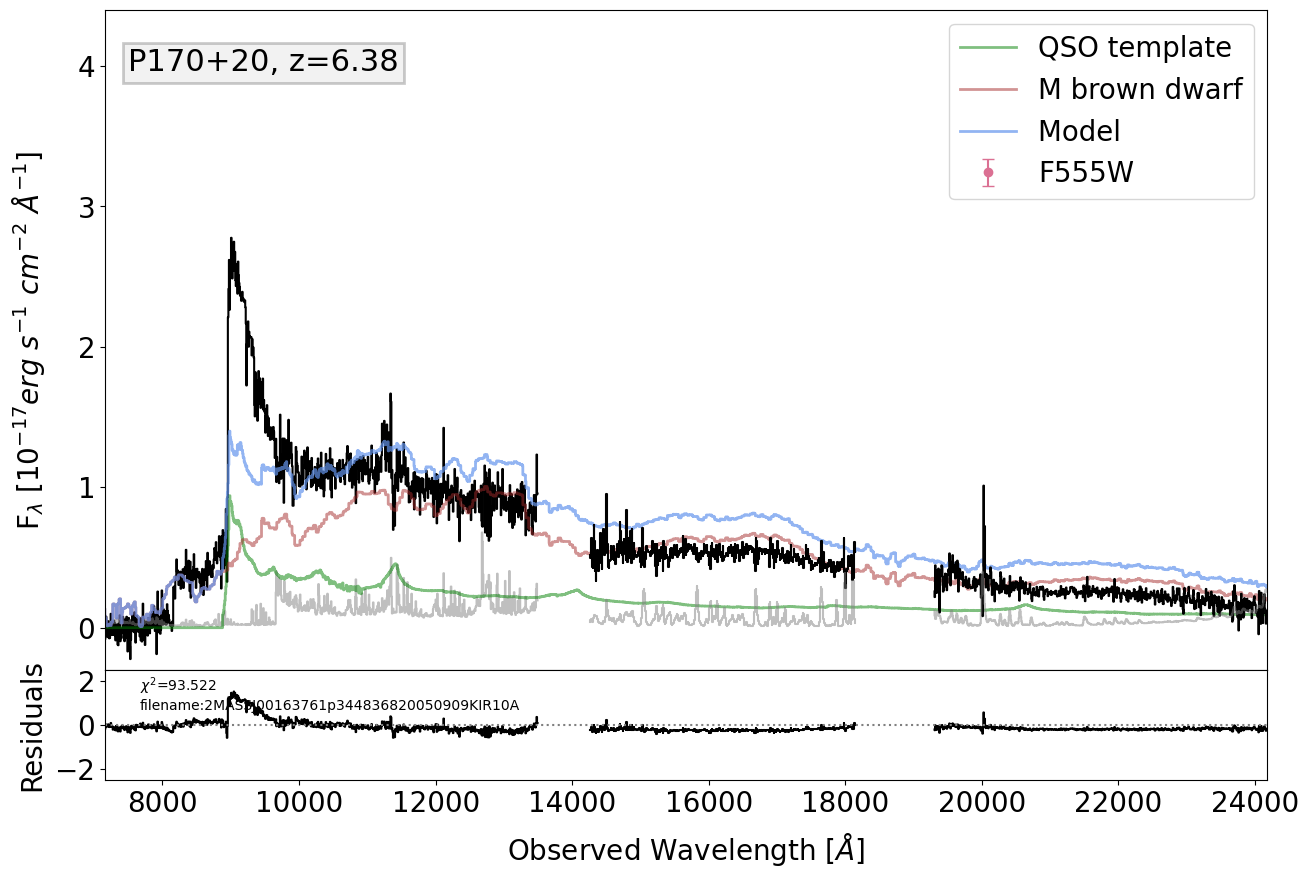

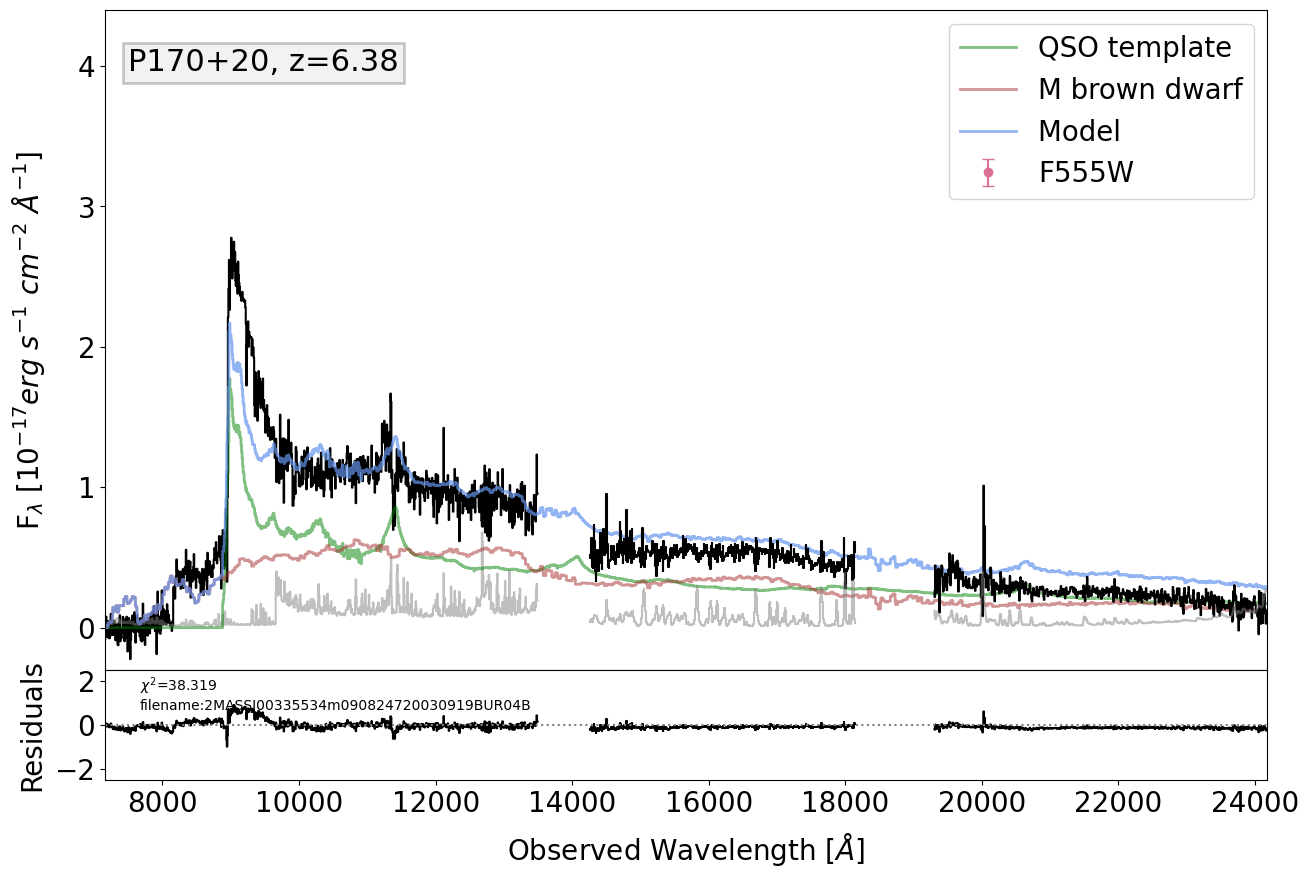

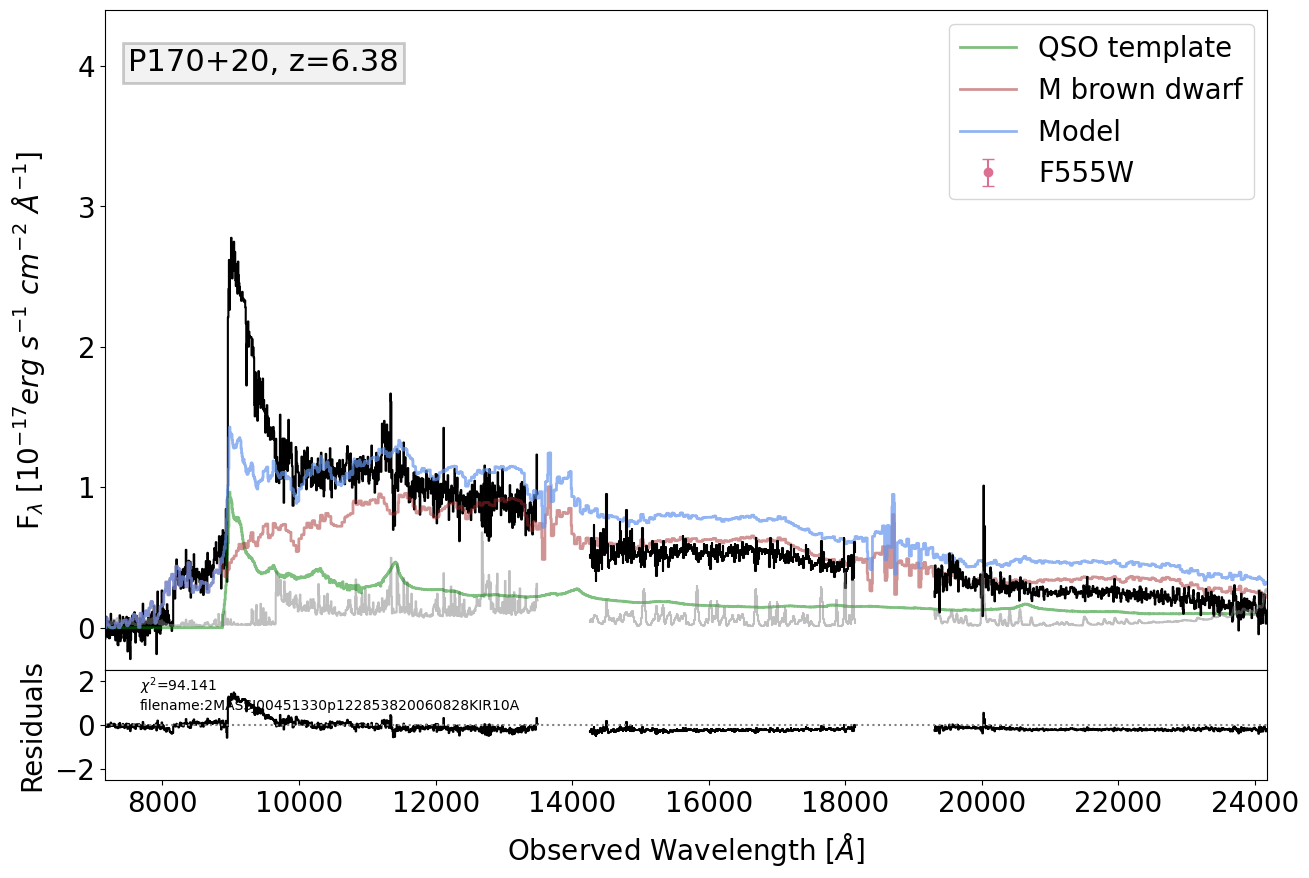

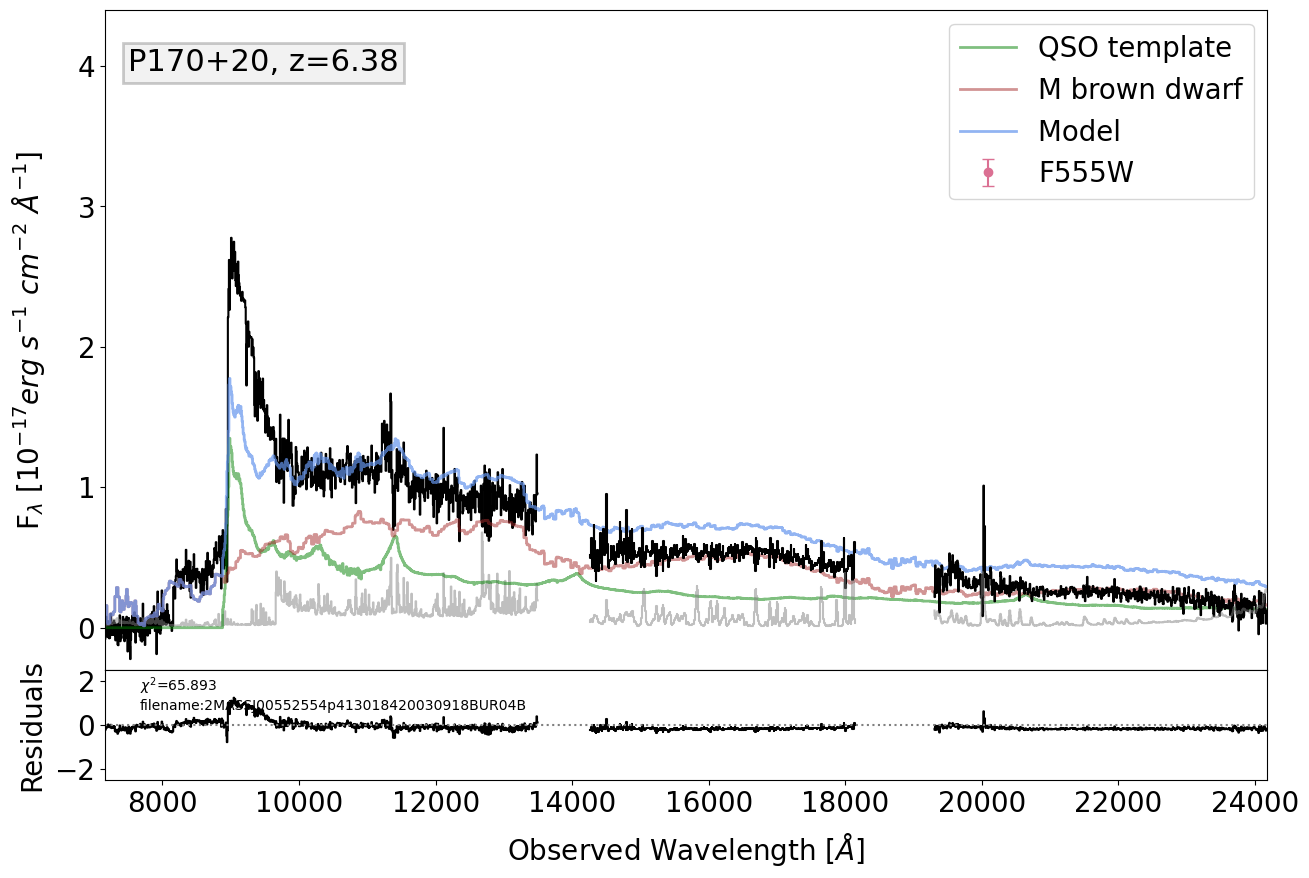

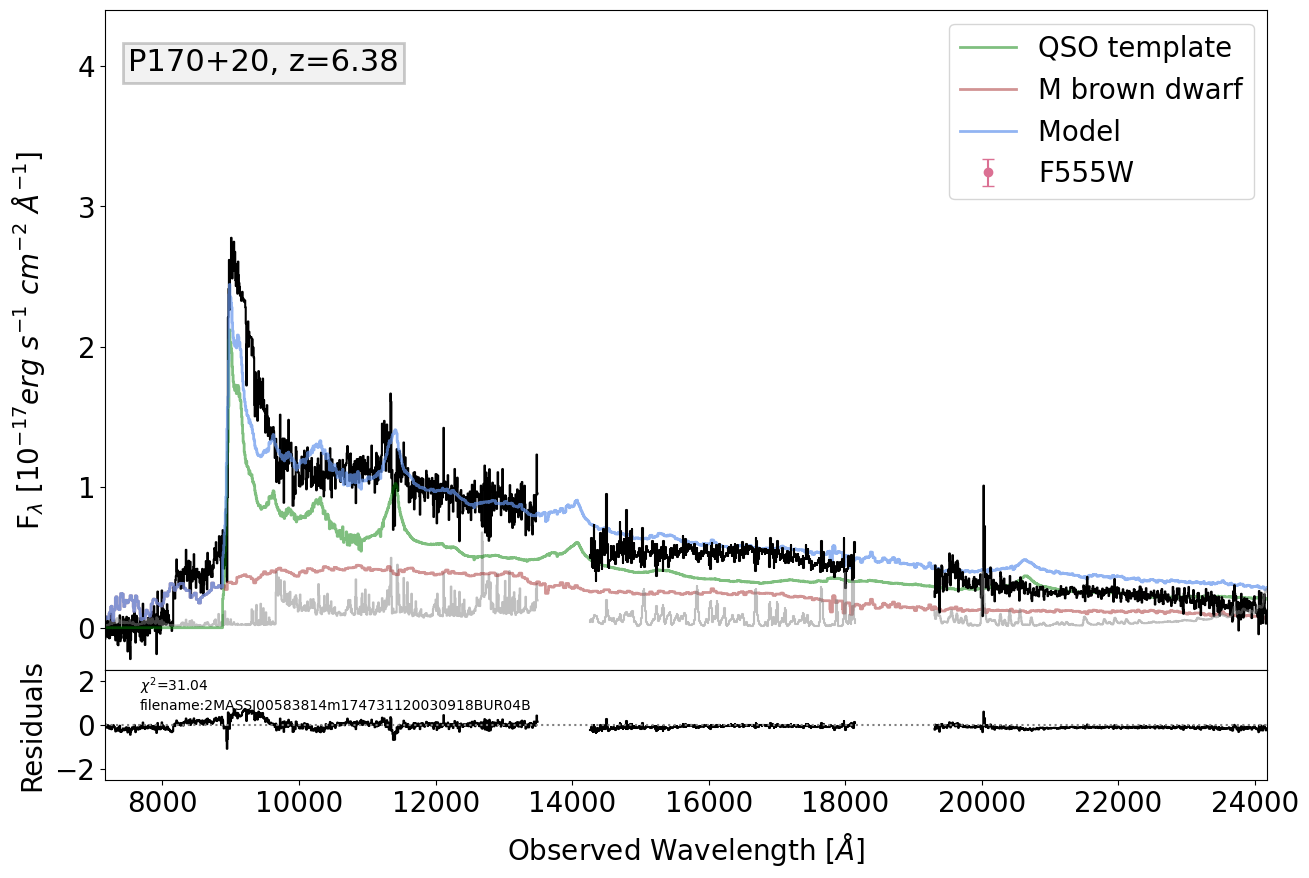

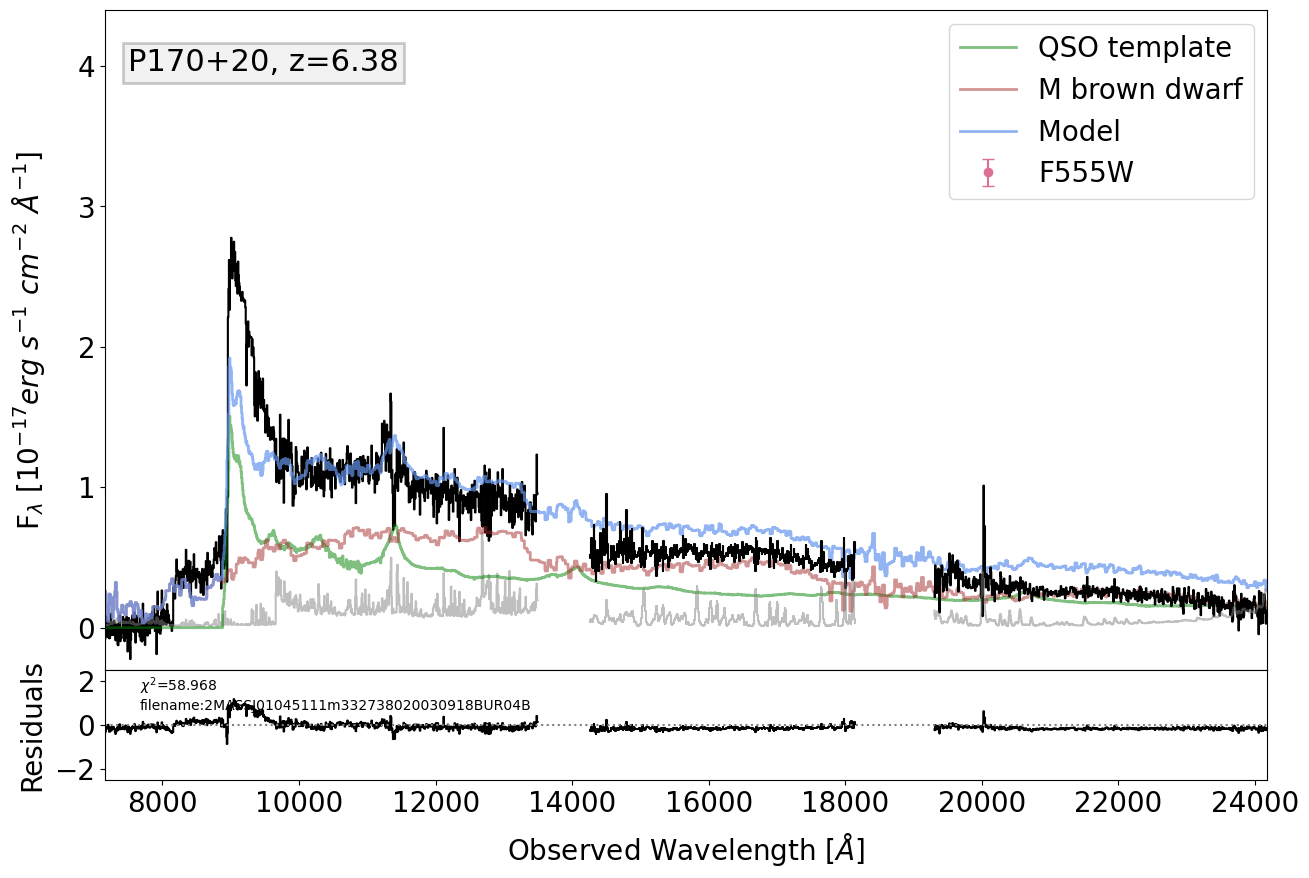


KeyboardInterrupt



In [40]:
#Upload libraries necessary for plots
from matplotlib.ticker import MaxNLocator
import matplotlib.ticker as ticker
import matplotlib.gridspec as gridspec
import astropy.units as units
from specutils.manipulation import FluxConservingResampler
from specutils import Spectrum1D
import os
from astropy.table import Table

#Define function to test the Mdwarf models and save them
def Mdarf_function(filename):
    #Read templates
    complete_route = os.path.join(route, filename)
    table = Table.read(complete_route, format='ascii')
    #Resample BD template
    newfluxbd=table['col2']*1e-17*units.erg/units.s/units.cm**2/units.AA
    newwavebd=table['col1']*1e4*units.AA
    newerrbd=table['col3']*1e-17*units.erg/units.s/units.cm**2/units.AA
    #convert to Spectrum from specutils 
    input_specbd=Spectrum1D(spectral_axis=newwavebd,flux=newfluxbd) 
    input_spec_errbd=Spectrum1D(spectral_axis=newwavebd,flux=newerrbd)
    #Resample here same grid as all data
    fluxconbd = FluxConservingResampler()
    new_spec_fluxconbd = fluxconbd(input_specbd, new_disp_grid)
    #Define region to fit BD template to region below Ly-alpha
    maskcurve=(originaldata_wave>969.47*(z+1))&(originaldata_wave<1210*(1+z))
    bdspectra=new_spec_fluxconbd.flux.value[maskcurve]
    #Function to fit BD to data
    def databrownd(x,c):
        f = c*bdspectra
        return f
    popt,pcov=curve_fit(databrownd,xdata=originaldata_wave[maskcurve],ydata=originaldata_flux[maskcurve],p0=[2.2])
    factorcbd=popt[0]
    #### Mask to select regions of fit
    maskresqso1=(originaldata_wave>1215*(1+z))&(originaldata_wave<13500) #13500 because I cut the noisy LBT data
    maskresqso2=(originaldata_wave>1940.29*(z+1))&(originaldata_wave<2469.47*(z+1))
    maskresqso3=(originaldata_wave>2618.72*(z+1))&(originaldata_wave<3283.58*(z+1))
    maskresqso=maskresqso1|maskresqso2 |maskresqso3
    bdscale=new_spec_fluxconbd.flux.value*factorcbd
    residualbddata=originaldata_flux-bdscale
    residualbddatac=tabc['FLUX'][maskresqso]
    #Function to fit residuals
    def residual(x,c):
        f = c*residualbddatac
        return f
    #mask_no_nan = ~np.isnan(tabc['FLUX'])
    popt2,pcov2=curve_fit(residual,xdata=originaldata_wave[maskresqso],ydata=residualbddata[maskresqso],p0=[4.2])
    factorcresqso=popt2[0]
    #print('factor qso', factorcresqso)
    ###########
    #Note: sumspectra my model
    browndspectra=new_spec_fluxconbd.flux.value*factorcbd#*factorbdm3
    sumspectra=np.nan_to_num(browndspectra+(tabc['FLUX']*factorcresqso))#d
    substraction=originaldata_flux-sumspectra


    #Calculation of chi square
    mask1= (originaldata_wave>7156.777)&(originaldata_wave<13500)
    mask2= (originaldata_wave>14250)&(originaldata_wave<18150) 
    mask3= (originaldata_wave>19300)&(originaldata_wave<24181.477) 
    maskf= mask1 | mask2  | mask3
    chisquare=np.sum((substraction[maskf])**2/((originaldata_err[maskf])**2))  
    reducedchi=chisquare/(len(originaldata_flux[maskf])-2)

    #All plotting from here
    fig = plt.figure(figsize=(15, 10))
    gs = gridspec.GridSpec(2, 1, height_ratios=[3, 0.5])    
    ax1 = fig.add_subplot(gs[0])
    
    #First plot - Data first section
    ax1.step(originaldata_wave[mask1],originaldata_flux[mask1],color='black')
    ax1.step(originaldata_wave[mask1], originaldata_err[mask1] ,color='grey',alpha=0.5)
    
    #Templates and model all plot
    ax1.step(originaldata_wave,tabc['FLUX']*factorcresqso,label='QSO template',alpha=0.5,color='green',linewidth=2)
    ax1.step(originaldata_wave,browndspectra,label='M brown dwarf',alpha=0.5,color='brown',linewidth=2)
    ax1.step(originaldata_wave,sumspectra,label='Model ',color='cornflowerblue',alpha=0.7,linewidth=2)
    
    #First plot - Data second section
    ax1.step(originaldata_wave[mask2],originaldata_flux[mask2],color='black')
    ax1.step(originaldata_wave[mask2], originaldata_err[mask2] ,color='grey',alpha=0.5)

     #First plot - Data third section
    ax1.step(originaldata_wave[mask3],originaldata_flux[mask3],color='black')
    ax1.step(originaldata_wave[mask3], originaldata_err[mask3] ,color='grey',alpha=0.5)
    
    #ax1.legend(fontsize=19.9,loc='upper right')
    ax1.tick_params(labelbottom=False) 
    bbox=dict(facecolor='silver',   # Color de fondo
                  edgecolor='black',          # Borde
                  linewidth=2,
                  alpha=0.2)
    ax1.text(0.02,0.92,'P170+20, z='+str(z),va='center', rotation='horizontal',fontsize=22,bbox=bbox,transform=ax1.transAxes)
    ax1.set_ylabel('F$_{\lambda}$ $[10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1}]$',fontsize=20,labelpad=22)
    ax1.yaxis.set_tick_params(labelsize=20)
    #ax1.set_ylabel('$f_{\lambda}$ $(10^{-17} erg~s^{-1}~cm^{-2}~\AA^{-1})$',fontsize=16)
    ax1.set_xlim(5300,24181.477)#(7156.777,24181.477)
    ax1.set_ylim(-0.3e-17,4.4e-17)
    plt.errorbar(x=5361, y=3.2e-19, yerr=0.85e-18, fmt='o', capsize=4,label='F555W',color='palevioletred')

    ax1.get_yaxis().get_offset_text().set_visible(False)
    ax1.get_xaxis().get_offset_text().set_visible(False)
    ax1.legend(fontsize=19.9,loc='upper right')

    #Lower plot - Residuals
    ax2 = fig.add_subplot(gs[1], sharex=ax1)
    ax2.step(originaldata_wave[mask1],substraction[mask1],color='black')
    ax2.step(originaldata_wave[mask2],substraction[mask2],color='black')
    ax2.step(originaldata_wave[mask3],substraction[mask3],color='black')
    ax2.axhline(y=0,color='grey',linestyle='dotted')

    ax2.xaxis.set_tick_params(labelsize=20)
    ax2.set_ylim(-2.5e-17, 2.5e-17)
    ax2.get_yaxis().get_offset_text().set_visible(False)
    ax2.set_xlim(7156.777,24181.477)#(7156.777,24181.477)
    
    ax2.set_ylabel('Residuals',fontsize=20,labelpad=6)
    
    #ax1.ticklabel_format(useOffset=False)

    plt.xlabel(r'Observed Wavelength [$\AA$]',fontsize=20,ha='center', va='center',labelpad=23)
    #plt.xscale('log') #Graficar en log
    plt.subplots_adjust(hspace=0.0)
    
    ax2.yaxis.set_tick_params(labelsize=20)
    
    #Include chi-square in plots
    ax2.text(0.03, 0.95, '$\chi^2$='+str(np.round(reducedchi,3))+'\n'+'filename:'+filename, transform=ax2.transAxes,
             fontsize=10, verticalalignment='top')
    
    #Here we save the models in a new folder to choose the best one. All models include the chisquare value
    exit_name = os.path.splitext(filename)[0] + '.png'
    exit_route="\\MBD\\results2" 
    route_plot = os.path.join(exit_route, exit_name)
    #plt.savefig(route_plot,bbox_inches='tight') #Disable in case you dont want to save them
    plt.show()
    plt.close()
    
    
# Route for the folder where all the Mdwarf models are
route = "\\MBD\\BDtemplates" 

#Here for Mdwarf loop / Loop will test all the templates of Mdwarf and calculate the chisquare to select one

for file_name in os.listdir(route):
    if os.path.isfile(os.path.join(route, file_name)):
        try:
            Mdarf_function(file_name)  # Here pass the name of the file
        except Exception:
            continue  # Go to next one in case of error